In [ ]:
import numpy as np
import matplotlib.pyplot as plt

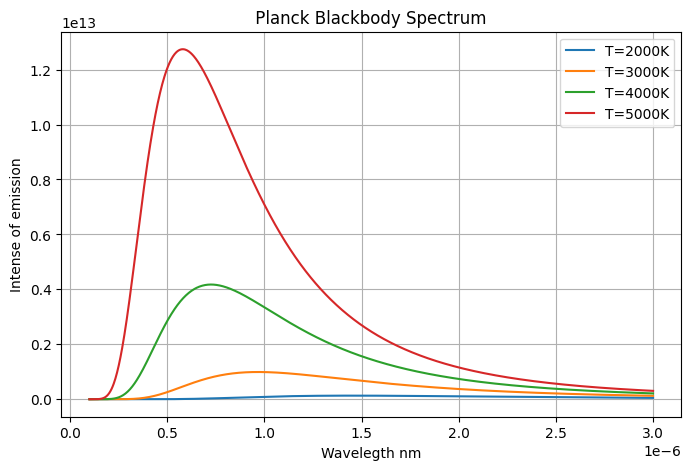

In [ ]:
lambda_range=np.linspace(100e-9,3000e-9,1000)
h = 6.626e-34
c = 3e8
k = 1.38e-23
temperatures=[2000,3000,4000,5000]
def planck(lambda_range,T):
    return (2*h*c**2)/((lambda_range**5)*(np.exp(h*c/(lambda_range*k*T)) - 1))
plt.figure(figsize=(8, 5))
for T in temperatures:
    plt.plot(lambda_range, planck(lambda_range,T),label=f"T={T}K")
plt.title(" Planck Blackbody Spectrum ")
plt.xlabel("Wavelegth nm")
plt.ylabel("Intense of emission")
plt.legend()
plt.grid(True)
plt.show()

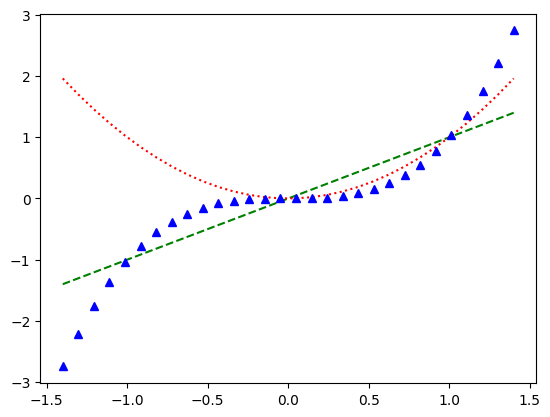

In [ ]:
x = np.linspace(-1.4, 1.4, 30)
plt.plot(x, x, 'g--', x, x**2, 'r:', x, x**3, 'b^')
plt.show()

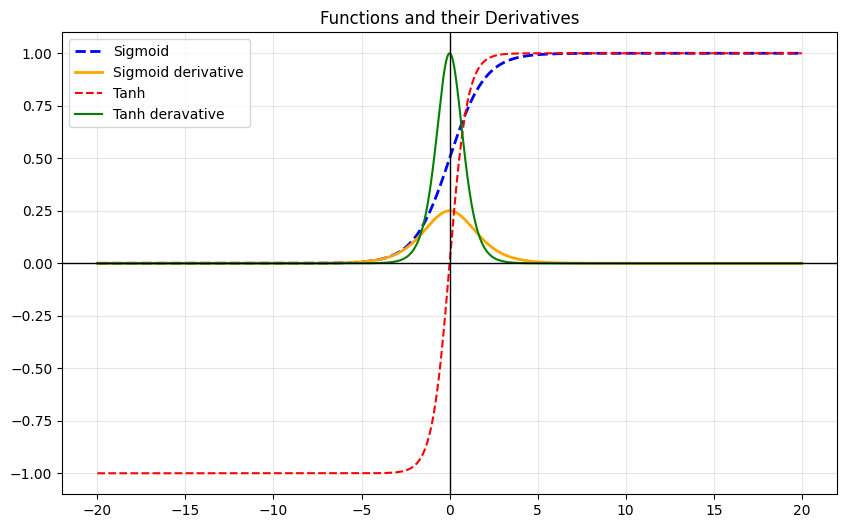

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-20, 20, 100000)

sigmoid = 1 / (1 + np.exp(-x))

sigmoid_derivative = sigmoid * (1 - sigmoid)

plt.figure(figsize=(10, 6))

plt.plot(x, sigmoid, "b--", label="Sigmoid", linewidth=2)

plt.plot(x, sigmoid_derivative, "orange", label="Sigmoid derivative", linewidth=2)

plt.plot(x, np.tanh(x), "r--", label="Tanh")

plt.plot(x, 1 - np.tanh(x)**2, "g-", label="Tanh deravative")


plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("Functions and their Derivatives")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

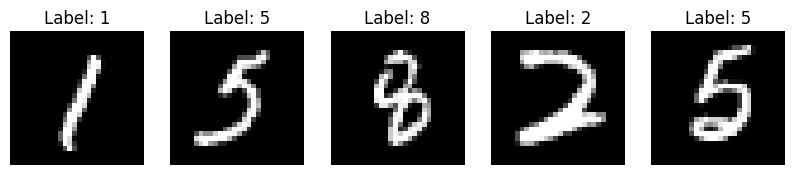


Model                     | Accuracy   | Time      
--------------------------------------------------
Logistic Regression       | 0.8820     | 11.88     
Random Forest             | 0.9485     | 8.29      
SVM (RBF)                 | 0.9320     | 21.83     
KNN (K=3)                 | 0.9015     | 0.02      
Naive Bayes               | 0.5575     | 0.09      
Gradient Boosting         | 0.9050     | 276.92    

Best accuracy model: Random Forest (0.9485)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import time

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"]

X_subset, _, y_subset, _ = train_test_split(X, y, train_size=10000, stratify=y, random_state=42)

plt.figure(figsize=(10, 4))
for index, (image, label) in enumerate(zip(X_subset[:5], y_subset[:5])):
    plt.subplot(1, 5, index + 1)
    plt.imshow(image.reshape(28, 28), cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')
plt.show()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_subset)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_subset, test_size=0.2, random_state=42
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM (RBF)": SVC(kernel='rbf'),
    "KNN (K=3)": KNeighborsClassifier(n_neighbors=3),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50)
}

results = {}

print(f"\n{'Model':<25} | {'Accuracy':<10} | {'Time':<10}")
print("-" * 50)

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    results[name] = acc
    print(f"{name:<25} | {acc:<10.4f} | {train_time:<10.2f}")

best_model = max(results, key=results.get)
print(f"\nBest accuracy model: {best_model} ({results[best_model]:.4f})")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
transform=transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))])
trainset=torchvision.datasets.CIFAR10(root='./data',train=True,download=True,transform=transform)
trainloader=DataLoader(trainset,batch_size=64,shuffle=True,num_workers=2)
testset=torchvision.datasets.CIFAR10(root='./data',train=False,download=True,transform=transform)
testloader=DataLoader(testset,batch_size=64,shuffle=True,num_workers=2)
class CIFAR10Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1=nn.Conv2d(3,32,kernel_size=3,padding=1)
        self.pool=nn.MaxPool2d(2,2)
        self.conv2=nn.Conv2d(32,64,kernel_size=3,padding=1)
        self.pool=nn.MaxPool2d(2,2)
        self.fc1=nn.Linear(64*8*8,512)
        self.fc2=nn.Linear(512,10)
    def forward(self,x):
        x=self.pool(F.relu(self.conv1(x)))
        x=self.pool(F.relu(self.conv2(x)))
        x=x.view(-1,64*8*8)
        x=F.relu(self.fc1(x))
        logits=self.fc2(x)
        return logits
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=CIFAR10Net().to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.AdamW(model.parameters(),lr=0.001)
epochs=10
for epoch in range(epochs):
    model.train()
    running_loss=0.0
    for images,labels in trainloader:
        images,labels=images.to(device),labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        outputs=model(images)
        loss=criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()
    print(f"Training Epoch [{epoch+1}/{epochs}], Training Loss: {running_loss/len(trainloader):.4f}")

model.eval()
correct=0
total=0
with torch.no_grad():
    for i,(images,labels) in testloader:
        images,labels=images.to(device),labels.to(device)
        outputs=model(images)
        _,predicted=torch.max(outputs.data,1)
        total+=labels.size(0)
        correct+=(predicted==labels).sum().item()
print(f"Accuracy on testset: {100*predicted/total:.2f}%")

100%|██████████| 170M/170M [00:03<00:00, 45.8MB/s]


Training Epoch [1/10], Training Loss: 1.2656
Training Epoch [2/10], Training Loss: 0.8997
Training Epoch [3/10], Training Loss: 0.7441
Training Epoch [4/10], Training Loss: 0.6383
Training Epoch [5/10], Training Loss: 0.5461
Training Epoch [6/10], Training Loss: 0.4626
Training Epoch [7/10], Training Loss: 0.3943
Training Epoch [8/10], Training Loss: 0.3360
Training Epoch [9/10], Training Loss: 0.2782
Training Epoch [10/10], Training Loss: 0.2327


ValueError: too many values to unpack (expected 2)

Precision: 0.9638 | Recall: 0.9638 | F1 Score: 0.9638


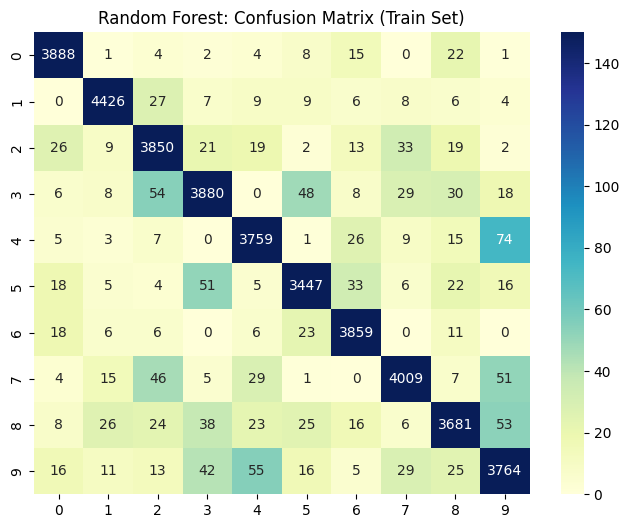

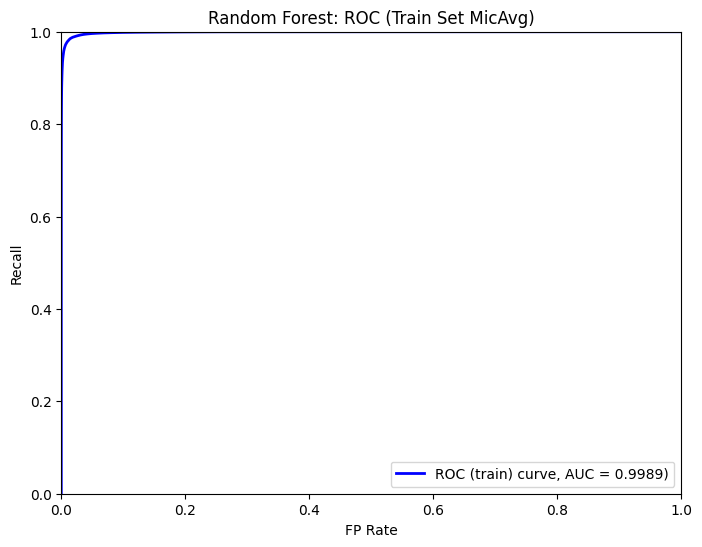

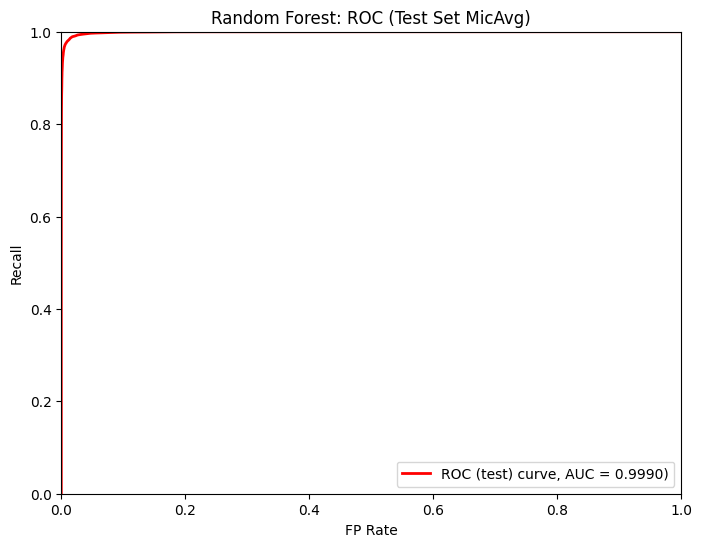

In [ ]:
print(f"Precision: {p:.4f} | Recall: {r:.4f} | F1 Score: {f:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(conMatrix, annot=True, fmt='d', cmap='YlGnBu', vmax=150)
plt.title('Random Forest: Confusion Matrix (Train Set)')
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC (train) curve, AUC = {auc_train:.4f})')
plt.axis([0, 1, 0, 1])
plt.xlabel('FP Rate')
plt.ylabel('Recall')
plt.title('Random Forest: ROC (Train Set MicAvg)')
plt.legend(loc="lower right")
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(fpr_test, tpr_test, color='red', lw=2, label=f'ROC (test) curve, AUC = {auc_test:.4f})')
plt.axis([0, 1, 0, 1])
plt.xlabel('FP Rate')
plt.ylabel('Recall')
plt.title('Random Forest: ROC (Test Set MicAvg)')
plt.legend(loc="lower right")
plt.show()

Precision: 0.9638 | Recall: 0.9638 | F1 Score: 0.9638


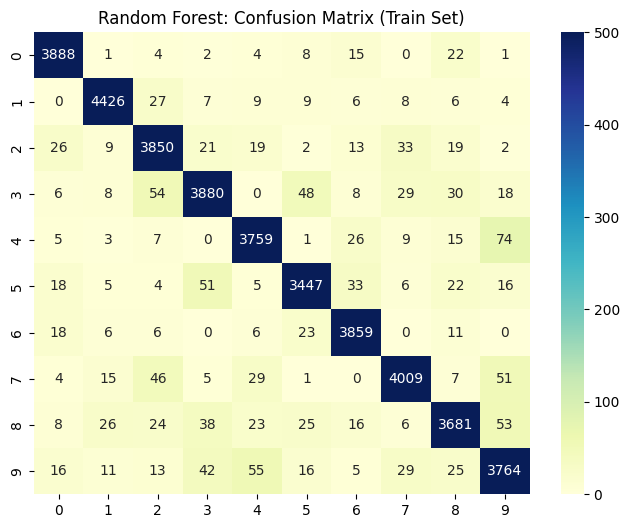

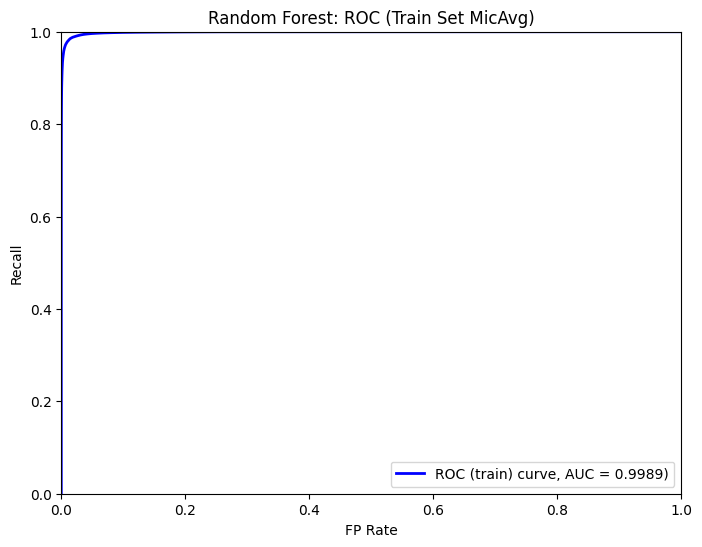

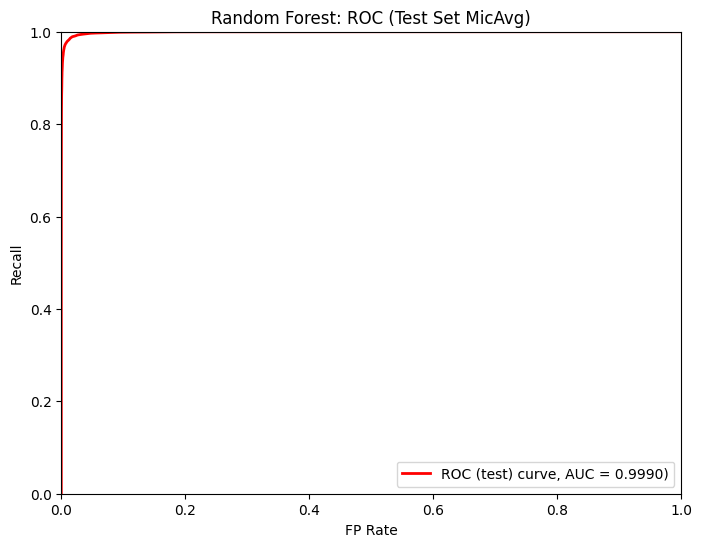

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist["data"], mnist["target"]
X_sub, _, y_sub, _ = train_test_split(X, y, train_size=50000, stratify=y, random_state=1488)
X_train, X_test, y_train, y_test = train_test_split(X_sub, y_sub, test_size=0.2, stratify=y_sub, random_state=1488)

full_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RandomForestClassifier(n_estimators=100, n_jobs=-1))
])
full_pipeline.fit(X_train,y_train)

y_scores=cross_val_predict(full_pipeline,X_train,y_train,cv=5,method="predict_proba")
classes=np.unique(y_train)
y_train_pred=classes[np.argmax(y_scores,axis=1)]
test_scores = full_pipeline.predict_proba(X_test)

p = precision_score(y_train,y_train_pred,average='macro')
r = recall_score(y_train,y_train_pred,average='macro')
f = f1_score(y_train,y_train_pred,average='macro')


conMatrix = confusion_matrix(y_train, y_train_pred)


y_train_bin = label_binarize(y_train, classes=classes)
fpr, tpr, _ = roc_curve(y_train_bin.ravel(), y_scores.ravel())
auc_train = roc_auc_score(y_train_bin.ravel(), y_scores.ravel())


y_test_bin = label_binarize(y_test, classes=classes)
fpr_test, tpr_test, _ = roc_curve(y_test_bin.ravel(), test_scores.ravel())
auc_test = roc_auc_score(y_test_bin.ravel(), test_scores.ravel())

In [ ]:

%pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.4 MB/s eta 0:00:00


In [ ]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt
model = YOLO("yolo26n.pt")
results = model.predict(source="0", conf=0.25, iou=0.45, device=0)
res = results
annotated_frame = res.plot()
annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.



NotImplementedError: 'source=0' webcam not supported in Colab and Kaggle notebooks. Try running 'source=0' in a local environment.